# EEG Depression Classification: Raw vs Engineered Features 

## Objective
This project investigates how different feature representations affect the classification of Major Depressive Disorder (MDD) using EEG data. 

We compares:
- Welch-Based spectral features vs raw EEG signals
- Classical ML vs deep learning (Logistic Regression, SVM)
- Deep learning (CNN, LSTM)
- Linear vs nonlinear structure (PCA, UMAP)
- Unsupervised (GMM)

Goal: Understand how representation affects performance. Can deep learning extract meaningful patterns directly from raw EEG signals?

## 1. Imports + Setup 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path 

from sklearn.model_selection import GroupKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    confusion_matrix, 
    ConfusionMatrixDisplay
)

from collections import Counter 

import umap
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, GlobalAveragePooling1D, Dense, Dropout, LSTM
from tensorflow.keras.optimizers import Adam



c:\Users\brend\miniconda3\envs\msse_277b_final_project\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Data + Segmentation 

Raw EEG segmentation: we segment each recording into fixed 10-second windows to create a dataset suitable for modeling.

In [27]:
# project root 
BASE_DIR = Path.cwd().parent

SEGMENTED_DATA_DIR = BASE_DIR / "data" / "segmented_data"

RESULTS_DIR = BASE_DIR / "results"


### Load Raw ( for CNN/LSTM later)

In [23]:
X_raw_10 = np.load(SEGMENTED_DATA_DIR / "X_raw_10sec.npy")
y_raw_10 = np.load(SEGMENTED_DATA_DIR / "y_raw_10sec.npy")
groups_raw_10 =np.load(SEGMENTED_DATA_DIR / "groups_raw_10sec.npy")

raw_seg_df_10= pd.read_csv(SEGMENTED_DATA_DIR / "raw_seg_df_10sec.csv")

print("Raw segmented X shape:", X_raw_10.shape)
print("Raw segmented y shape:", y_raw_10.shape)
print("Unique Patients:", len(np.unique(groups_raw_10)))

Raw segmented X shape: (7339, 20, 2560)
Raw segmented y shape: (7339,)
Unique Patients: 64


### Load Welch-based segmented data (for temporal analysis)

In [24]:
X_seg_5 = np.load(SEGMENTED_DATA_DIR / "X_seg_5sec.npy" )
y_seg_5 = np.load(SEGMENTED_DATA_DIR / "y_seg_5sec.npy")
groups_seg_5 = np.load(SEGMENTED_DATA_DIR / "groups_seg_5sec.npy")
seg_df_5 = pd.read_csv(SEGMENTED_DATA_DIR / "seg_df_5sec.csv")

X_seg_10 = np.load(SEGMENTED_DATA_DIR / "X_seg_10sec.npy" )
y_seg_10 = np.load(SEGMENTED_DATA_DIR / "y_seg_10sec.npy")
groups_seg_10 = np.load(SEGMENTED_DATA_DIR / "groups_seg_10sec.npy")
seg_df_10 = pd.read_csv(SEGMENTED_DATA_DIR / "seg_df_10sec.csv")

## 3. Raw Baseline (PCA + SVM)

We flatten raw segments and apply PCA before training an SVM classifier.

In [4]:
# flatten raw segments for modeling

X_raw_10_flat = X_raw_10.reshape(X_raw_10.shape[0], -1)

print("Flattened raw segmented X shape:", X_raw_10_flat.shape)

Flattened raw segmented X shape: (7339, 51200)


In [5]:
gkf = GroupKFold(n_splits=5)

pipeline_raw_pca_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=50, random_state=42)),
    ("clf", SVC(kernel="rbf", probability=True, random_state=42))
])

raw_pca_results = cross_validate(
    pipeline_raw_pca_svm,
    X_raw_10_flat,
    y_raw_10,
    groups=groups_raw_10,
    cv=gkf,
    scoring=["accuracy", "f1", "roc_auc"]
)

print("Raw + PCA + SVM accuracy:", raw_pca_results["test_accuracy"].mean())
print("Raw + PCA + SVM F1:", raw_pca_results["test_f1"].mean())
print("Raw + PCA + SVM ROC-AUC:", raw_pca_results["test_roc_auc"].mean())

Raw + PCA + SVM accuracy: 0.7028909271537475
Raw + PCA + SVM F1: 0.7784027681001386
Raw + PCA + SVM ROC-AUC: 0.807439685496161


## 4. Welch Temporal analysis

Although raw EEG signals were evaluated later, temporal resolution and ablation were performed using Welch-based band -power features because they provide stable and interpretable spectral representations. 

This section asks:
- What window size gives the strongest classification performance?
- Is MDD-related signal localized to specific time segments or distributed across the recording?

### Time Resolution 

In [28]:
window_results_df = pd.read_csv(
    RESULTS_DIR / "window_size_results.csv"
)

window_results_df

,window_sec,accuracy,f1,roc_auc
0,5.0,0.798763,0.812561,0.889488
1,10.0,0.827231,0.844465,0.908115


Window-size experiments were run once and saved to disk. Results are loaded here to avoid recomputation. 

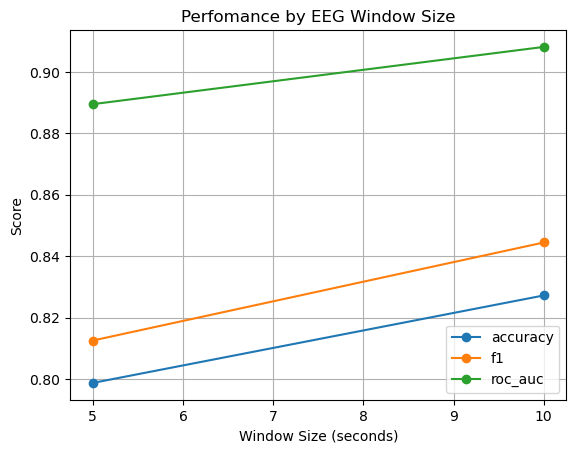

In [29]:
window_results_df.plot(
    x="window_sec",
    y=["accuracy", "f1", "roc_auc"],
    marker="o"
)

plt.xlabel("Window Size (seconds)")
plt.ylabel("Score")
plt.title("Perfomance by EEG Window Size")
plt.grid(True)
plt.show()

### Interpretation:
Performance improves when increasing window size from 5 to 10 seconds, suggesting that depression-related EEG patterns are better captured over longer temporal windows. 

### Temporal ablation (use 10 sec)

In [31]:
ablation_results_df = pd.read_csv(
    RESULTS_DIR / "temporal_ablation_10sec.csv"
)

baseline_ablation_df = pd.read_csv(
    RESULTS_DIR / "baseline_ablation_10sec.csv"
)

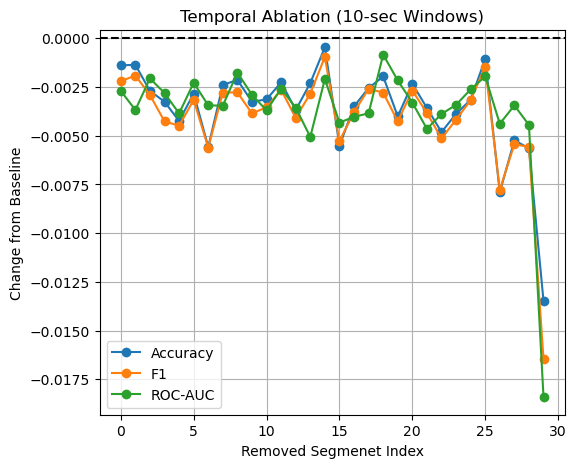

In [32]:
plt.figure(figsize=(6,5))

plt.plot(
    ablation_results_df["ablated_segment"],
    ablation_results_df["delta_accuracy"],
    marker="o",
    label="Accuracy"
)

plt.plot(
    ablation_results_df["ablated_segment"],
    ablation_results_df["delta_f1"],
    marker="o",
    label="F1"
)

plt.plot(
    ablation_results_df["ablated_segment"],
    ablation_results_df["delta_roc_auc"],
    marker="o",
    label="ROC-AUC"
)

plt.axhline(0, linestyle="--", color="black")

plt.xlabel("Removed Segmenet Index")
plt.ylabel("Change from Baseline")
plt.title("Temporal Ablation (10-sec Windows)")
plt.legend()
plt.grid(True)
plt.show()



Temporal ablation analysis showed that removing individual time segments resulted in small but consistent decreases in model performance across most of the recording. This indicates that informative EEG features are distributed throughout the signal rather than concentrated in a specific time window. While larger performance drops were observed in later segments, these are likely driven by reduced sample coverage rather than true signal importance. 

## 5. PCA Visualization 

In [6]:
scaler_raw = StandardScaler()
X_scaled = scaler_raw.fit_transform(X_raw_10_flat)

# PCA
pca = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance:", pca.explained_variance_ratio_.sum())

Explained variance: 0.655690505930747


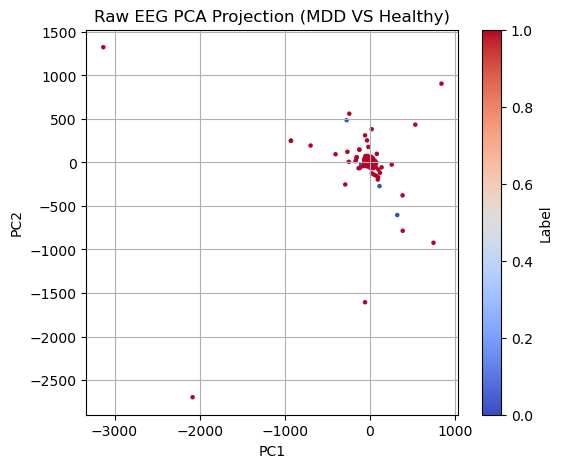

In [7]:
# PCA Plot (by label)
plt.figure(figsize=(6,5))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y_raw_10,
    cmap="coolwarm",
    s=5
)

plt.title("Raw EEG PCA Projection (MDD VS Healthy)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="Label")
plt.grid(True)
plt.show()

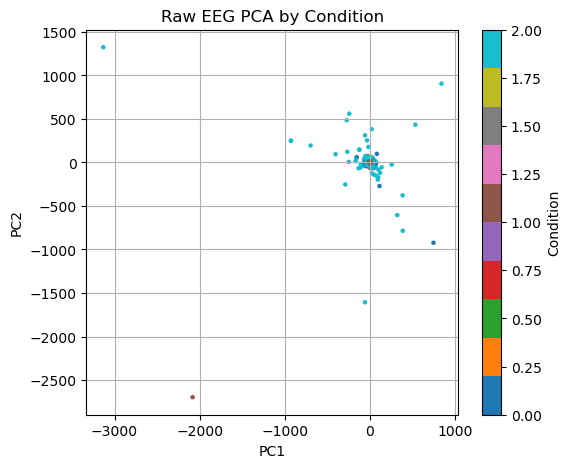

In [8]:
# PCA plot (by condition)
condition_codes = raw_seg_df_10["condition"].map({
    "eyesClosed": 0,
    "eyesOpen": 1,
    "P300": 2
})

plt.figure(figsize=(6,5))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=condition_codes,
    cmap="tab10",
    s=5
)

plt.title("Raw EEG PCA by Condition")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="Condition")
plt.grid(True)
plt.show()

## 6. UMAP Visualization 
Nonlinear Structure: UMAP

In [9]:
umap_model = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)

X_umap = umap_model.fit_transform(X_pca)

print("UMAP shape:", X_umap.shape)

c:\Users\brend\miniconda3\envs\msse_277b_final_project\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP shape: (7339, 2)


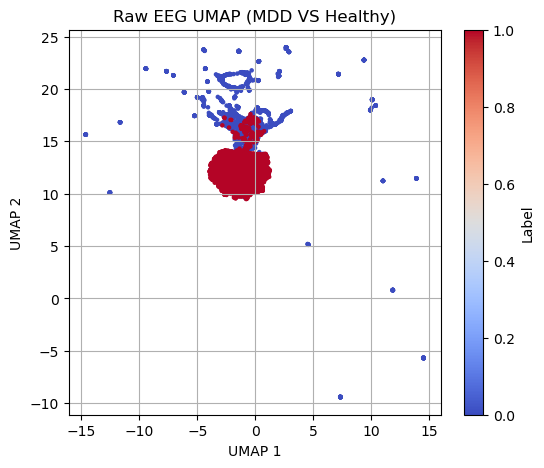

In [10]:
plt.figure(figsize=(6,5))

plt.scatter(
    X_umap[:,0],
    X_umap[:,1],
    c=y_raw_10,
    cmap="coolwarm",
    s=5
)

plt.title("Raw EEG UMAP (MDD VS Healthy)")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.colorbar(label="Label")
plt.grid(True)
plt.show()

## 7. GMM Clustering 
Unsupervised Clustering 

In [11]:
gmm = GaussianMixture(n_components=2, random_state=42)
labels = gmm.fit_predict(X_pca)

print(np.unique(labels, return_counts=True))

(array([0, 1], dtype=int64), array([7338,    1], dtype=int64))


c:\Users\brend\miniconda3\envs\msse_277b_final_project\lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


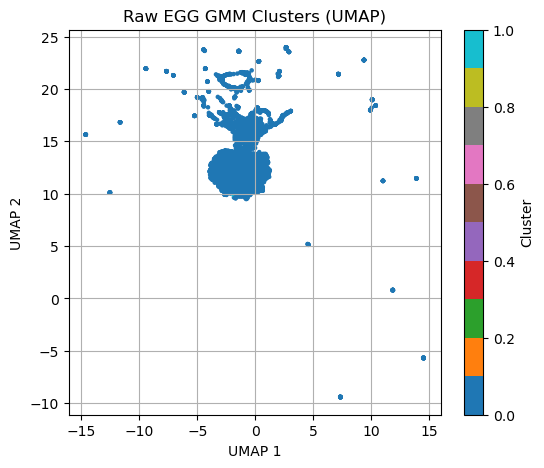

In [12]:
plt.figure(figsize=(6,5))

plt.scatter(
    X_umap[:,0],
    X_umap[:,1],
    c=labels,
    cmap="tab10",
    s=5
)

plt.title("Raw EGG GMM Clusters (UMAP)")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.colorbar(label="Cluster")
plt.grid(True)
plt.show()

Observation: GMM collapses into one dominant cluster, indicating poor separability in raw feature space.

## 8. Deep Learning on Raw EEG (CNN)

In [13]:
# Step 1 - Normalize (z_score)

def zscore_segments(X):
    """
    X.shape: (n_samples, n_channels, n_timepoints)
    z-score each channel within each sample
    """

    mean = X.mean(axis=2, keepdims=True)
    std = X.std(axis=2, keepdims=True)
    std[std == 0] = 1.0
    return (X - mean) / std 

X_raw_10_z = zscore_segments(X_raw_10)
print(X_raw_10_z.shape)

(7339, 20, 2560)


In [16]:
# step 2 - Reshape for CNN
X_cnn = np.transpose(X_raw_10_z, (0,2,1))
print("CNN input shape:", X_cnn.shape)

CNN input shape: (7339, 2560, 20)


In [17]:
## step 3 - Build CNN model

def build_cnn_model(input_shape):
    model = Sequential([
        Conv1D(32, kernel_size=7, activation='relu', input_shape=input_shape),
        MaxPooling1D(pool_size=2),

        Conv1D(64, kernel_size=5, activation='relu'),
        MaxPooling1D(pool_size=2),

        Conv1D(128, kernel_size=3, activation='relu'),
        GlobalAveragePooling1D(),

        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')

    ])

    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=["accuracy"]
    )

    return model

In [18]:
def evaluate_cnn_groupkfold(X, y, groups, n_splits=5, epochs=10, batch_size=32):
    gkf = GroupKFold(n_splits=n_splits)

    acc_scores = []
    f1_scores = []
    auc_scores = []

    fold_results = []

    for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups), start=1):
        print(f"\n===Fold {fold} ===")

        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model = build_cnn_model(input_shape=X.shape[1:])

        early_stop = tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=3,
            restore_best_weights=True
        )

        history = model.fit(
            X_train, 
            y_train, 
            validation_split=0.2,
            epochs=epochs,
            batch_size=batch_size,
            verbose=1,
            callbacks=[early_stop]
        )

        y_prob = model.predict(X_test).ravel()
        y_pred = (y_prob >= 0.5).astype(int)

        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_prob)

        acc_scores.append(acc)
        f1_scores.append(f1)
        auc_scores.append(auc)

        fold_results.append({
            "fold": fold,
            "accuracy": acc,
            "f1": f1,
            "roc_auc": auc
        })

        print(f"Fold {fold} accuracy: {acc:.4f}")
        print(f"Fold {fold} F1: {f1:.4f}")
        print(f"Fold {fold} ROC-AUC: {auc:.4f}")

    summary = {
        "accuracy": np.mean(acc_scores),
        "f1": np.mean(f1_scores),
        "roc_auc": np.mean(auc_scores),
        "fold_results": pd.DataFrame(fold_results)
}

    return summary 

In [19]:
# step 5 - Run CNN
cnn_results = evaluate_cnn_groupkfold(
    X_cnn,
    y_raw_10,
    groups_raw_10,
    n_splits=5,
    epochs=10,
    batch_size=32
)

print("\nCNN mean accuracy:", cnn_results["accuracy"])
print("CNN mean F1:", cnn_results["f1"])
print("CNN mean ROC-AUC:", cnn_results["roc_auc"])
cnn_results["fold_results"]


===Fold 1 ===


c:\Users\brend\miniconda3\envs\msse_277b_final_project\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 27s 138ms/step - accuracy: 0.8038 - loss: 0.3707 - val_accuracy: 0.7811 - val_loss: 2.0661
Epoch 2/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 18s 122ms/step - accuracy: 0.9131 - loss: 0.2045 - val_accuracy: 0.8132 - val_loss: 2.0266
Epoch 3/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 21s 140ms/step - accuracy: 0.9564 - loss: 0.1170 - val_accuracy: 0.7997 - val_loss: 2.0493
Epoch 4/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 22s 145ms/step - accuracy: 0.9638 - loss: 0.1007 - val_accuracy: 0.7363 - val_loss: 3.0605
Epoch 5/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 21s 143ms/step - accuracy: 0.9704 - loss: 0.0826 - val_accuracy: 0.8284 - val_loss: 3.1633
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step
Fold 1 accuracy: 0.9572
Fold 1 F1: 0.9585
Fold 1 ROC-AUC: 0.9887

===Fold 2 ===


c:\Users\brend\miniconda3\envs\msse_277b_final_project\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 24s 143ms/step - accuracy: 0.8381 - loss: 0.3294 - val_accuracy: 0.7671 - val_loss: 2.4642
Epoch 2/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 21s 140ms/step - accuracy: 0.9377 - loss: 0.1492 - val_accuracy: 0.7509 - val_loss: 3.6499
Epoch 3/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 20s 137ms/step - accuracy: 0.9550 - loss: 0.1153 - val_accuracy: 0.7756 - val_loss: 3.5836
Epoch 4/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 21s 140ms/step - accuracy: 0.9789 - loss: 0.0614 - val_accuracy: 0.7679 - val_loss: 5.5647
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step
Fold 2 accuracy: 0.8722
Fold 2 F1: 0.8627
Fold 2 ROC-AUC: 0.9546

===Fold 3 ===


...

c:\Users\brend\miniconda3\envs\msse_277b_final_project\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 25s 144ms/step - accuracy: 0.8292 - loss: 0.3384 - val_accuracy: 0.8089 - val_loss: 2.0902
Epoch 2/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 20s 137ms/step - accuracy: 0.9204 - loss: 0.1884 - val_accuracy: 0.7747 - val_loss: 3.0629
Epoch 3/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 20s 135ms/step - accuracy: 0.9509 - loss: 0.1260 - val_accuracy: 0.7867 - val_loss: 2.7868
Epoch 4/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 21s 144ms/step - accuracy: 0.9607 - loss: 0.0930 - val_accuracy: 0.7440 - val_loss: 3.6768
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step
Fold 4 accuracy: 0.8995
Fold 4 F1: 0.9112
Fold 4 ROC-AUC: 0.9783

===Fold 5 ===


c:\Users\brend\miniconda3\envs\msse_277b_final_project\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 22s 130ms/step - accuracy: 0.8498 - loss: 0.3265 - val_accuracy: 0.7964 - val_loss: 1.3955
Epoch 2/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 19s 127ms/step - accuracy: 0.9367 - loss: 0.1572 - val_accuracy: 0.7189 - val_loss: 1.9877
Epoch 3/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 19s 128ms/step - accuracy: 0.9446 - loss: 0.1385 - val_accuracy: 0.7359 - val_loss: 1.7633
Epoch 4/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 19s 129ms/step - accuracy: 0.9651 - loss: 0.0969 - val_accuracy: 0.8543 - val_loss: 1.0981
Epoch 5/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 19s 128ms/step - accuracy: 0.9693 - loss: 0.0814 - val_accuracy: 0.7053 - val_loss: 1.5131
Epoch 6/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 21s 146ms/step - accuracy: 0.9751 - loss: 0.0661 - val_accuracy: 0.7053 - val_loss: 2.1881
Epoch 7/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 19s 130ms/step - accuracy: 0.9761 - loss: 0.0646 - val_accuracy: 0.7257 - val_loss: 2.1086
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step
Fold 5 accuracy: 0.7973
Fold 5 F1: 0.7964
F

,fold,accuracy,f1,roc_auc
0,1,0.957223,0.958475,0.988682
1,2,0.872211,0.862745,0.954608
2,3,0.807018,0.847222,0.832756
3,4,0.899460,0.911151,0.978325
4,5,0.797279,0.796448,0.859892


CNNs learn local temporal patterns directly from raw EEG signals. Unlike classical models, they do not require feature engineering such as Welch's method.

## 9.LSTM Model on Raw EEG

The LSTM was trained on the same 10-second raw EEG segments as the CNN. Because training is computationally expensive, the fold-level LSTM results were saved and loaded here. 

In [34]:
lstm_results_df = pd.read_csv(RESULTS_DIR / "lstm_results.csv")
lstm_summary_df = pd.read_csv(RESULTS_DIR / "lstm_summary.csv")

lstm_results_df

,fold,accuracy,f1,roc_auc
0,1,0.727209,0.783287,0.792490
1,2,0.814740,0.828964,0.860482
2,3,0.817814,0.859081,0.812402
3,4,0.846154,0.871477,0.875958
4,5,0.725170,0.753959,0.774404


In [35]:
lstm_summary = lstm_summary_df.iloc[0]

print("LSTM mean accuarcy:", lstm_summary["accuracy"])
print("LSTM mean F1:", lstm_summary["f1"])
print("LSTM mean ROC-AUC:", lstm_summary["roc_auc"])

LSTM mean accuarcy: 0.7862174
LSTM mean F1: 0.8193536000000001
LSTM mean ROC-AUC: 0.8231472


In [36]:
comparison_df = pd.DataFrame([
    {
        "method": "Welch + SVM (10 sec)",
        "accuracy": 0.827231,
        "f1": 0.844465,
        "roc_auc": 0.908115
    },
    {
        "method": "Raw + PCA + SVM (10 sec)",
        "accuracy": 0.702891,
        "f1": 0.778403,
        "roc_auc": 0.807440
    },
    {
        "method": "Raw + CNN (10 sec)",
        "accuracy": cnn_results["accuracy"],
        "f1": cnn_results["f1"],
        "roc_auc": cnn_results["roc_auc"]
    },
    {
         "method": "Raw + LSTM (10 sec)",
        "accuracy": lstm_summary["accuracy"],
        "f1": lstm_summary["f1"],
        "roc_auc": lstm_summary["roc_auc"]
    }
])

comparison_df

,method,accuracy,f1,roc_auc
0,Welch + SVM (10 sec),0.827231,0.844465,0.908115
1,Raw + PCA + SVM (10 sec),0.702891,0.778403,0.807440
2,Raw + CNN (10 sec),0.866638,0.875208,0.922853
3,Raw + LSTM (10 sec),0.786217,0.819354,0.823147
